<img src="./logo_UTN.svg" align="right" width="150" /> 

#### Teoría de los Circuitos 2

# **Tarea Semanal 0**
#### Nahuel Siles

Se efectuara un analisis del siguiente circuito a fin de cumplir las consignas dadas.

<img src="./CircuitoTS0.PNG" />

## **Consignas**

1. Obtener la Función Transferencia $\frac{V1}{V2}$, módulo, fase y diagrama de polos y ceros
2. Proponga una norma de frecuencia e impedancia  de forma tal de llegar a una transferencia normalizada
3.  Simule la transferencia normalizada en Python.
4. Simule la red en LTspice y obtenga su respuesta en frecuencia.
5. ¿ Que tipo de filtro es ? Analizar el caso del MF-103  ¿ Utiliza la misma red ?

**Bonus**
1. Obtener una **red normalizada** que responda a la función hallada en 2
2. Verifique los resultados de 1 y 2 mediante el módulo de simulación **SymPy**
3. Analice similitudes y diferencias con ambas redes del TP1-Ej7

## **Resolución**

En primera instancia se hallara la función transferencia $H(s)= \frac{V1}{V2}$, em módulo, la fase y el diagrama de polos y ceros

In [6]:
from IPython.display import IFrame
IFrame("./Transferencia.pdf", width=1000, height=1000)

### **Verificación mediante SymPy (Función Transferencia)**

In [7]:
# Módulos necesarios
import sympy as sp
from IPython.display import display

# Variables
s = sp.symbols('s')
[R1, R2, R3, C1] = sp.symbols('R1 R2 R3 C1')
[V1, V2, Vx] = sp.symbols('V1 V2 Vx')

# Ecuaciones resultantes de analisis de corrientes
Eq1 = sp.Eq( (V1-Vx)*s*C1 , Vx/R3 )
Eq2 = sp.Eq( (V1-Vx)/R1 , (Vx-V2)/R2 )

# Despeje de Vx en Eq1 y reemplazo en Eq2
Vx_solve = sp.solve(Eq1, Vx)
Eqf = Eq2.subs(Vx, Vx_solve[0])

# Despeje de V2
V2s = sp.solve(Eqf , V2)

# Función Transferencia
H = sp.simplify(V2s[0]/V1)

# Separación del numerador y denominador
[num , den] = sp.fraction(H)
numP = sp.Poly(num, s)
denP = sp.Poly(den, s)

# Guardo el coeficiente de S del denominador
Coeff_S = denP.all_coeffs()[0]

# Función Transferencia final
Hs = sp.simplify(num/Coeff_S) / sp.simplify(den/Coeff_S)

display(Hs)

(s - R2/(C1*R1*R3))/(s + 1/(C1*R3))

### **Normalización de H(S)**

Siendo la función transferencia: 

$$
H(S)=\frac{S-\frac{R2}{C1R3R1}}{S+\frac{1}{C1R3}}
$$

Se tomará como frecuencia de normalización: 
$$
\Omega_w= \frac{1}{C1R3}
$$

Entonces:
$$
S=$\frac{1}{C1R3}
$$

Reemplazando y simplificando:

$$
H($)=\frac{$-\frac{R2}{R1}}{$+1}
$$

Suponiendo que $R2=R1$:
$$
H($)=\frac{$-1}{$+1}
$$

Ahora tomando como norma de impedancia a $R3$:
$$
\Omega_Z=R3
$$
y suponiendo que $R3=1$ y $\Omega_w=1$
$$
\frac{1}{C1}=1
$$
$$
C1=1
$$

### **Verificación mediante SymPy (Normalización)**

In [8]:
# Variable nueva
s_n = sp.symbols('s_n')

# Frecuencia normalizada
W0 = 1/(C1*R3)

# Reemplazo de s
Hs_t = Hs.subs(s, s_n*W0)
Hs_t = sp.simplify(Hs_t)

# Separación del numerador y denominador
[num_N , den_N] = sp.fraction(Hs_t)
denPs = sp.Poly(den_N, s_n)

# Guardo el coeficiente de S del denominador
Coeff_Sn = denPs.all_coeffs()[0]

# Función Transferencia final normalizada
Hsn = sp.simplify(num_N/Coeff_Sn) / sp.simplify(den_N/Coeff_Sn)

display(Hsn)

(s_n - R2/R1)/(s_n + 1)

### **Simulación en Python**

Obtenida la transferencia normalzada, se procederá a corroborar el modulo, la fase y el diagrama de polos y ceros mediante Python. Se efectuaran 3 simulaciones diferentes tomando en cuenta los valores que pueden tomar $R2$ y $R1$

Primero se cargan las funciones y módulos necesarios para la simulación.

In [9]:
# Módulos para los gráficos
import matplotlib as mpl
from matplotlib import pyplot as plt

# Módulos numéricos y de funciones científicas
import numpy as np
from scipy import signal as sig

# Funciones de PyTC2
from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay, analyze_sys

#%%  Inicialización de librerías
mpl.rcParams['figure.figsize'] = (9,9)

# Modificamos el largo y ancho de la salida
fig_sz_x = 14
fig_sz_y = 13
fig_dpi = 80 # dpi

# tamaño de la tipografía
fig_font_size = 11

plt.rcParams.update({'font.size':fig_font_size})

#### Caso 1 (R2=R1)

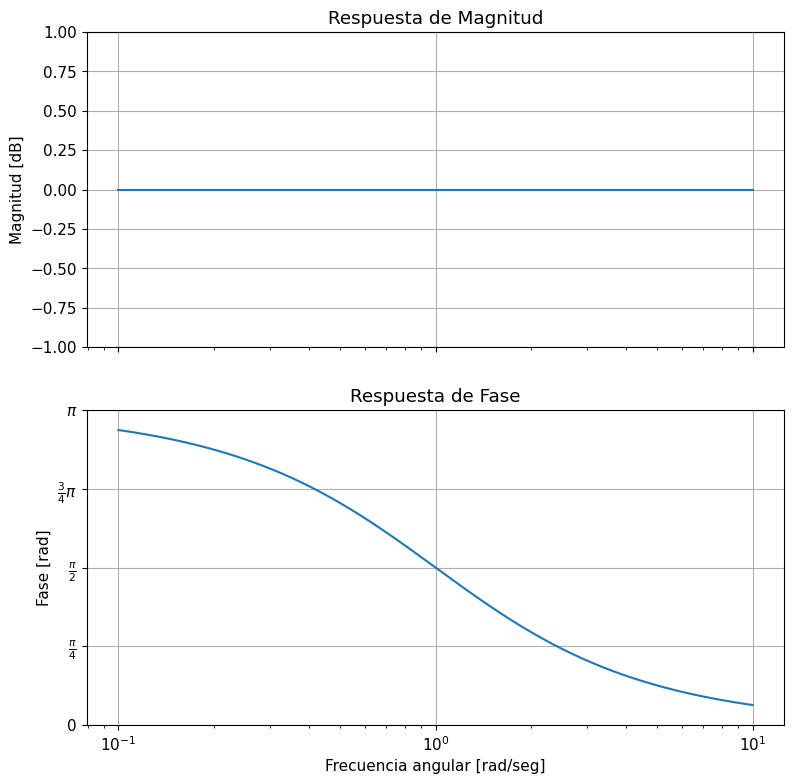

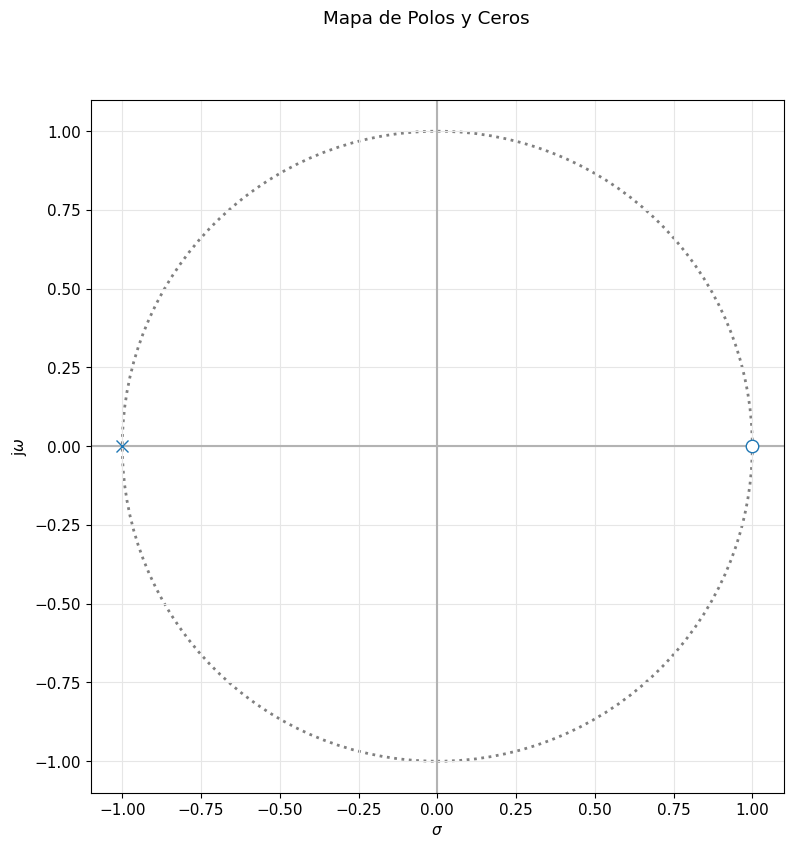

In [10]:
# Valor de los Resistores
R1=R2=1

# Función Transferencia
num = [1,-R2/R1]
den = [1,1]

H1= sig.TransferFunction(num,den)

# Gráfico de módulo, fase y diagrama de Bode
_, axes_hdl = bodePlot(H1)
pzmap(H1)

# Ajuste de escala
axes_hdl[0].set_ylim(-1,1)
plt.show()

#### Caso 2 (R2>R1)

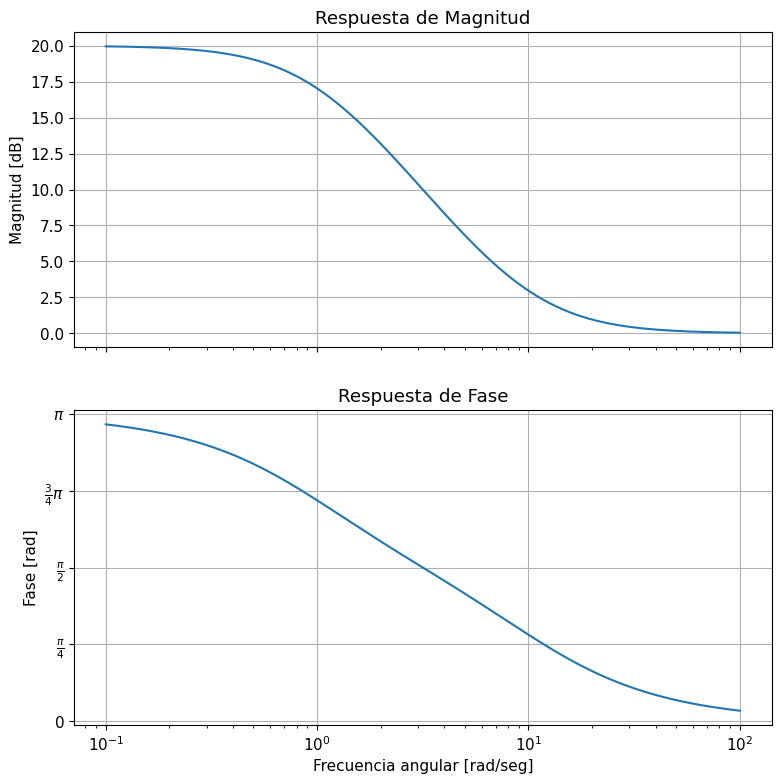

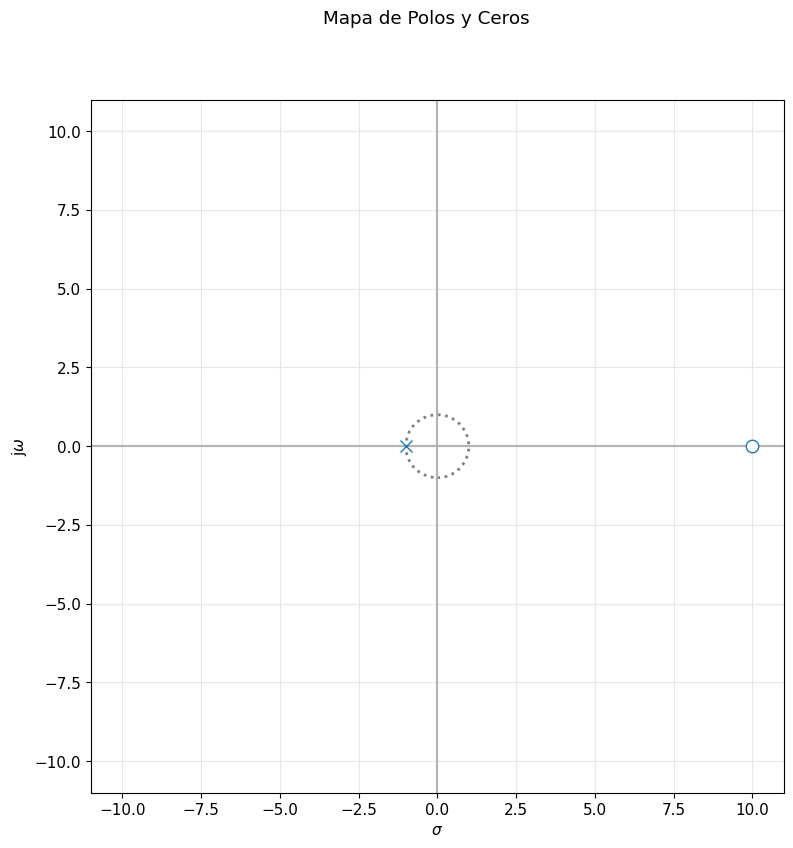

In [11]:
# Valor de los Resistores
R1=1
R2=10

# Función Transferencia
num = [1,-R2/R1]
den = [1,1]
H2= sig.TransferFunction(num,den)

# Gráfico de módulo, fase y diagrama de Bode
_, axes_hdl = bodePlot(H2)
pzmap(H2)

plt.show()

#### Caso 3 (R2<R1)

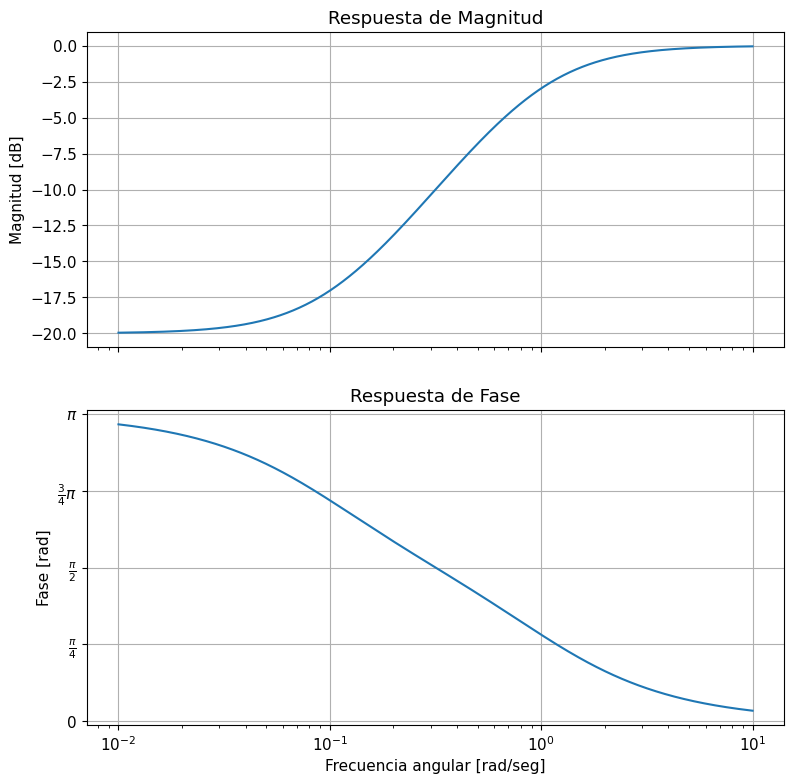

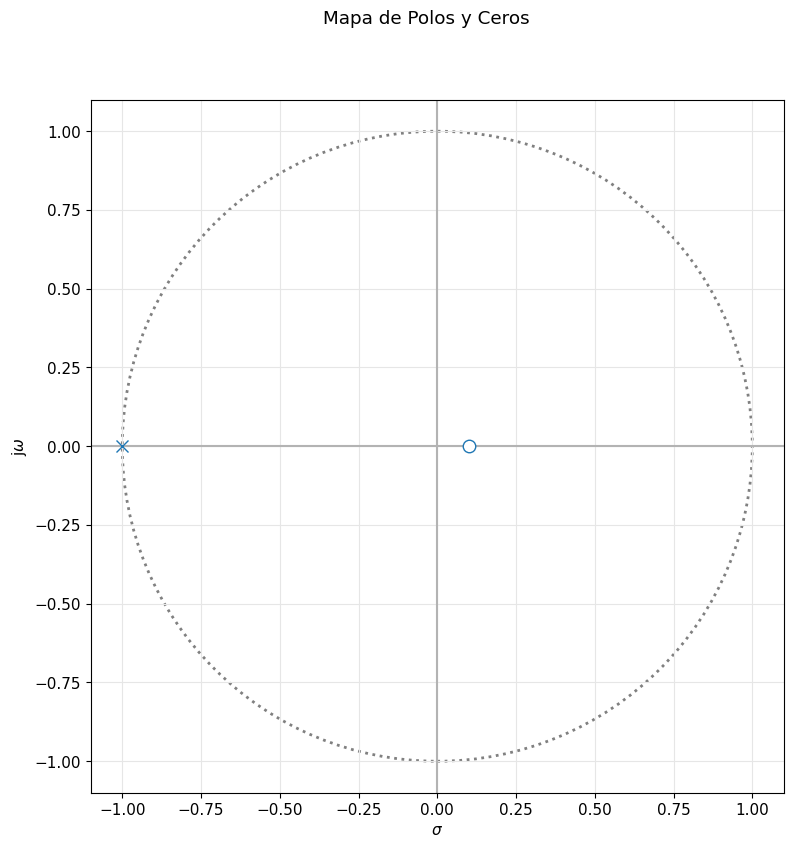

In [12]:
# Valor de los Resistores
R1=10
R2=1

# Función Transferencia
num = [1,-R2/R1]
den = [1,1]
H3= sig.TransferFunction(num,den)

# Gráfico de módulo, fase y diagrama de Bode
_, axes_hdl = bodePlot(H3)
pzmap(H3)

plt.show()

### **Simulación en LtSpice**

A continuación se encuentran tanto el circuito analizado como su respuesta en frecuencia para el caso 1

<img src="./LtSpiceTS0.PNG" />

### **Tipo de Filtro**

El filtro es un pasa todo de primer orden en el caso de que las resistencias $R1$ y $R2$ sean iguales. Si las resistencias nombradas anteriormente son diferentes, el filtro sigue comportandose como un pasa todo con la difenrencia en que las frecuencias mas bajas $(\approx 100Hz)$ se ven amplificadas o atenuadas.